In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime,timedelta
import scipy.io as sio
from time import time
from bayes_opt import  BayesianOptimization
import pickle as pkl
import multiprocessing
import cvxpy as cp

import matplotlib.pyplot as plt
#解决中文显示问题
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False
#设定全局图像的字体大小
plt.rcParams['font.size']= 14
plt.rcParams['axes.labelsize']= 14
plt.rcParams['axes.titlesize']= 14
plt.rcParams['legend.fontsize']= 14

In [2]:
test_result_path = r'/home/van/projects/长周期/backtest/backtest_result8.21'
path_dailyData = r'/media/van/data16b1/data/long_strategy/data_frames'
support_path = r'/media/van/data16b1/data/trade_support5'
path3 = r"/home/van/projects/长周期/backtest"
support_dates = sorted(os.listdir(support_path))

def load_daily_data(data_name):
    os.chdir(path_dailyData)
    return pd.read_feather(data_name+'.feather')

idx_name = 'zz1000'
initial_money = 20000 * 10000

if idx_name=='zz1000':
    idx_name2 = '中证1000'
    future_basis = 0.08
elif idx_name=='zz500':
    idx_name2 = '中证500'
    future_basis = 0.04
elif idx_name=='hs300': 
    idx_name2 = '沪深300'
    future_basis = 0.0

In [3]:
# 场外信息
high_limit = load_daily_data('stk_ztprice').replace(0,np.nan).ffill()
low_limit = load_daily_data('stk_dtprice').replace(0,np.nan).ffill()
pre_close = load_daily_data('stk_preclose').replace(0,np.nan).ffill()
adj_factor = load_daily_data('stk_adjfactor').replace(0,np.nan).ffill()
close = load_daily_data('stk_close').replace(0,np.nan).ffill()
last_zt_df = (close == high_limit).shift(1).fillna(False).astype(int)

upper_price = pre_close + 0.9 * (high_limit - pre_close) # 个股达到涨停价的90%就不再买入
lower_price = pre_close + 0.9 * (low_limit - pre_close) # 个股达到跌停价的90%就不再卖出
adj = adj_factor / adj_factor.shift(1)
zs_day = load_daily_data('idx_close')[idx_name2].dropna()
zs_nv = zs_day #/ zs_day.iloc[0]

os.chdir(path3)
vwap_df = pd.read_feather('vwap.fea')

os.chdir(r'/home/van/projects/open_strategy/share_data/signal_ti0930_zz1000_score')
file_list = sorted([x for x in os.listdir() if x[-4:]=='.csv'])
score_dict = {}
for file in file_list:
    td_score = pd.read_csv(file).set_index("Code")["Score"]
    td_score.index = ["{:0>6d}".format(x) for x in td_score.index]
    score_dict[file[:8]] = td_score
scores = pd.DataFrame(score_dict).T.sort_index().dropna(how='all') # .shift(1)
date_list = sorted([x for x in scores.index.tolist() ])# [-100:]
date_list = [x for x in date_list if x>='20250101']

/tmp/ipykernel_1666190/3231705904.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  last_zt_df = (close == high_limit).shift(1).fillna(False).astype(int)


In [4]:
scores

,000001,000002,000004,000006,000007,000008,000009,000010,000011,000012,...,688787,688788,688789,688793,688798,688799,688800,688819,688981,689009
20250102,-0.845539,-0.414924,0.132277,0.624328,1.102590,-1.174472,-0.234851,0.751808,0.577244,-0.195517,...,-0.673567,0.251603,-0.783870,-0.116721,-0.431923,-0.201085,-0.967387,-0.798631,-0.109356,-0.367968
20250103,-0.793694,-0.394688,0.182727,0.170676,0.675878,0.207032,-0.354709,0.253363,0.453971,-0.091134,...,-0.855782,0.224855,-0.419449,-0.911553,-0.123810,0.170644,-0.395583,-0.477562,-0.195720,-0.602966
20250106,-1.370877,-0.442550,0.443091,0.620925,0.392721,0.374599,-0.313834,0.619735,0.437833,-0.214926,...,-1.218636,0.401878,-0.544162,-0.835244,-0.869962,-0.349891,-2.825518,-0.443833,-0.291585,-0.807115
20250107,-0.695634,-0.314677,0.797303,0.571454,0.684314,0.333624,-0.512532,0.787101,0.377285,-0.514358,...,-0.060437,0.414095,-0.953986,-2.375843,-0.683910,0.131001,-2.216015,-0.749230,-0.440057,-0.820910
20250108,-0.637041,-0.246077,0.669712,0.411193,0.862853,0.181477,-0.205650,-0.357860,0.249422,-0.112144,...,-0.365025,0.094673,-0.521979,-1.114241,-0.372518,0.096471,-0.891143,-0.593358,-0.478813,-0.866502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20251028,-0.704976,-0.764599,NaN,-0.820329,1.047786,0.335596,0.294423,0.969967,0.118446,0.159343,...,-0.293074,0.542277,-0.036935,0.198914,-0.693895,0.344356,-0.065255,-0.117462,-0.148252,-0.458263
20251029,-0.750651,-1.614946,NaN,-0.460013,0.919403,0.350612,0.348717,0.921627,-1.673378,-0.002338,...,-0.211791,0.400585,-0.073063,0.625502,-0.020981,0.166796,-0.287824,-0.889796,-0.104216,-0.515884
20251030,-0.973189,-0.818651,NaN,-0.342950,0.375849,0.094333,-0.406672,0.857727,-0.266273,-0.466102,...,-0.198308,0.289594,0.027879,0.225704,-0.681447,0.701746,0.254473,-0.273509,-0.501236,-0.524223
20251031,-0.648650,-0.506508,NaN,-0.510660,0.407633,0.286522,0.276145,0.808843,0.076336,-0.240243,...,-0.260091,-1.741370,-0.399751,0.349112,-0.209527,0.420576,-0.078589,-0.622808,-0.305343,-0.313241


In [26]:
_data_cache = {
    'daily_price': {},
    'daily_support': {}
}

def get_daily_price(date):
    if date not in _data_cache['daily_price']:
        td_open = vwap_df.loc[date].dropna()
        td_close = close.loc[date].dropna()
        td_preclose = pre_close.loc[date].dropna()
        td_adj = adj.loc[date].replace(1,np.nan).dropna().to_dict()
        td_score = scores.loc[date].dropna()
        td_upper = upper_price.loc[date].dropna()
        td_lower = lower_price.loc[date].dropna()
        last_zt = last_zt_df.loc[date].dropna()
        return td_open,td_close,td_preclose,td_adj,td_score,td_upper,td_lower,last_zt
    else:
        return _data_cache['daily_price'][date]

def get_daily_support(str_date):
    if str_date not in _data_cache['daily_support']:
        os.chdir(support_path)
        last_date = [x for x in support_dates if x <str_date][-1]
        td_support = pd.read_feather(last_date)# .set_index('index')
        all_columns = td_support.columns.tolist()
        sub_code_list = td_support.loc[(td_support['ipo_dates']>120) & (td_support['st']==0)].index.tolist() # 上市120交易日以上、非ST股票
        sub_code_list = [x for x in sub_code_list if x[0] in ['0','3','6']]
        td_citic = td_support[[x for x in all_columns if 'citic_b_' in x]].reindex(sub_code_list).fillna(0)
        td_cmvg = td_support[[x for x in all_columns if 'cmvg_b_' in x]].reindex(sub_code_list).fillna(0)
        style_fac = td_support[[x for x in all_columns if 'style_b_' in x]].reindex(sub_code_list).fillna(0)
        td_mem = td_support[idx_name+'_member'].reindex(sub_code_list).dropna()
        
        zz_citic = td_support.loc['idx_'+idx_name][td_citic.columns.tolist()]
        zz_cmvg = td_support.loc['idx_'+idx_name][td_cmvg.columns.tolist()]
        zz_style = td_support.loc['idx_'+idx_name][style_fac.columns.tolist()]
        
        return td_citic,td_cmvg,td_mem,zz_citic,zz_cmvg,style_fac,zz_style,sub_code_list
    else:
        return _data_cache['daily_support'][str_date]

# 预加载所有日期数据
def preload_all_data():
    print("开始预加载数据到内存...")
    # 预加载daily_price数据
    for date in date_list:
        _data_cache['daily_price'][date] = get_daily_price(date)
    # 预加载daily_support数据
    for date in date_list:
        _data_cache['daily_support'][date] = get_daily_support(date)
    print("数据预加载完成")

In [27]:
def solve_problem(code_list,x_last,score0,stk_low0,stk_high0,tot_amt0,sell_max0,
                td_mem0,td_mem_amt0,td_ind0,td_ind_up0,td_ind_down0,td_cmvg0,td_cmvg_up0,td_cmvg_down0,
                td_style,style_up0,style_down0,solver='SCIPY'):
    
    def make_parameter(param_s,fill=0):
        return param_s.reindex(code_list).replace([np.inf,-np.inf],np.nan).fillna(fill).values #cp.Parameter(
    
    x = cp.Variable(len(code_list)) # 个股市值向量
    x_last = make_parameter(x_last)
    x.value = x_last # 初始化x向量,加速寻优
    score0 = make_parameter(score0)
    stk_low0 = make_parameter(stk_low0)
    stk_high0 = make_parameter(stk_high0)
    if sum( stk_low0 > stk_high0) >0 :
        print('stk_low0 > stk_high0')
    td_mem0 = make_parameter(td_mem0)
    td_ind0 = make_parameter(td_ind0)
    td_ind_up0 = td_ind_up0.values
    td_ind_down0 = td_ind_down0.values
    if sum( td_ind_down0 > td_ind_up0) >0 :
        print('td_ind_down0 > td_ind_up0')
    td_cmvg0 = make_parameter(td_cmvg0)
    td_cmvg_up0 = td_cmvg_up0.values
    td_cmvg_down0 = td_cmvg_down0.values
    if sum( td_cmvg_down0 > td_cmvg_up0) >0 :
        print('td_cmvg_down0 > td_cmvg_up0')
    td_style = make_parameter(td_style)
    style_up0 = style_up0.values
    style_down0 = style_down0.values
    if sum( style_down0 > style_up0) >0 :
        print('style_down0 > style_up0')
    

    # 最大化目标：平均得分
    obj = cp.Maximize(x@score0) # 后续需要加上换手率惩罚
    constraints = [
    # 个股持仓上下限约束，不仅考虑相对指数的偏离，还考虑相对昨仓的偏离和黑名单
    x >= stk_low0,
    x <= stk_high0,
    # 卖出金额约束
    cp.sum(cp.abs(x-x_last)-x+x_last) <= 2 * sell_max0,
    # 个股总持仓约束
    cp.sum(x) <= tot_amt0,
    # 成分股约束
    x @ td_mem0 >= td_mem_amt0,
    # 行业分布约束
    x @ td_ind0 <= td_ind_up0,
    x @ td_ind0 >= td_ind_down0,
    # 市值分组约束
    x @ td_cmvg0 <= td_cmvg_up0,
    x @ td_cmvg0 >= td_cmvg_down0,
    # 其他线性风格因子约束
    x @ td_style <= style_up0,
    x @ td_style >= style_down0,
    ]
    problem = cp.Problem(obj, constraints)
    problem.solve(solver=solver,ignore_dpp=True) # solver='CLARABEL'
    return pd.Series(x.value,index=code_list,dtype=float)


def analyse(nv,plotting=False,title=''):
    ret = nv['strategy'].diff().dropna()
    mean_ret = ret.mean() * 250
    mean_std = ret.std() * np.sqrt(250)
    sharp_ratio = mean_ret / mean_std
    dd_s = nv['strategy'].cummax() - nv['strategy']
    mean_dd = dd_s.mean()
    max_dd = dd_s.max()
    dd_date = dd_s.sort_values(ascending=False).index[0]

    new_zs = nv['zs']
    zs_ret = new_zs.diff().dropna()
    excess_ret = ret - zs_ret
    rel_nv = 1 + excess_ret.cumsum()
    # excess_ret.loc['20240130':'20240219'] = 0
    ana_ex_ret = excess_ret.mean() * 250
    ana_ex_std = excess_ret.std() * np.sqrt(250)
    info_ratio = ana_ex_ret / ana_ex_std
    rel_dd_s =  rel_nv.cummax() - rel_nv
    # rel_dd_s.loc['20240130':'20240219'] = 0
    rel_mean_dd = rel_dd_s.mean()
    rel_max_dd = rel_dd_s.max()
    rel_dd_date = rel_dd_s.sort_values(ascending=False).index[0]
    info_ratio2 = ana_ex_ret / rel_max_dd

    nv_df = pd.concat([nv['strategy'], new_zs, rel_nv], axis=1,
                      keys=['策略净值', '基准指数', '超额净值'],
                      sort=False).fillna(1)
    
    if plotting is True:
        print('------绝对收益------')
        print('年化收益:' + str(mean_ret))
        print('年化波动:' + str(mean_std))
        print('夏普比率:' + str(sharp_ratio))
        print('平均回撤:' + str(mean_dd))
        print('最大回撤:' + str(max_dd))
        print('回撤日期:' + str(dd_date))
        print('------相对收益------')
        print('超额年化收益:' + str(ana_ex_ret))
        print('超额年化波动:' + str(ana_ex_std))
        print('超额夏普比率:' + str(info_ratio))
        print('超额平均回撤:' + str(rel_mean_dd))
        print('超额最大回撤:' + str(rel_max_dd))
        print('超额回撤日期:' + str(rel_dd_date))
        print('收益回撤比:' + str(info_ratio2))
        
        nv_df.plot(figsize=(16, 6),grid=True,title=title)
        plt.show()

    info_s = pd.Series([ana_ex_ret, ana_ex_std, info_ratio, rel_max_dd, rel_mean_dd, rel_dd_date, info_ratio2],
                       index=['超额年化收益', '超额年化波动', '超额夏普比率', '超额最大回撤', '超额平均回撤', '超额回撤日期', '收益回撤比'])
    return info_s, nv_df, rel_nv

def analyse2(nv,plotting=False):
    ret = nv['strategy'].diff().dropna()
    mean_ret = ret.mean() * 250
    mean_std = ret.std() * np.sqrt(250)
    sharp_ratio = mean_ret / mean_std
    dd_s = nv['strategy'].cummax() - nv['strategy']
    mean_dd = dd_s.mean()
    max_dd = dd_s.max()
    dd_date = dd_s.sort_values(ascending=False).index[0]

    new_zs = nv['zs']
    zs_ret = new_zs.diff().dropna()
    excess_ret = (ret - zs_ret - 0.08/250)# *0.8 # 扣除年华8%的基差，占用20%保证金
    rel_nv = 1 + excess_ret.cumsum()
    ana_ex_ret = excess_ret.mean() * 250
    ana_ex_std = excess_ret.std() * np.sqrt(250)
    info_ratio = ana_ex_ret / ana_ex_std
    rel_dd_s =  rel_nv.cummax() - rel_nv
    rel_mean_dd = rel_dd_s.mean()
    rel_max_dd = rel_dd_s.max()
    rel_dd_date = rel_dd_s.sort_values(ascending=False).index[0]
    info_ratio2 = ana_ex_ret / rel_max_dd

    nv_df = pd.concat([nv['strategy'], new_zs, rel_nv], axis=1,
                      keys=['strategy', 'index', 'relative'],
                      sort=False).fillna(1)
    
    if plotting is True:
        print('-------------纯多头表现------------')
        print('年化收益:' + str(mean_ret))
        print('年化波动:' + str(mean_std))
        print('夏普比率:' + str(sharp_ratio))
        print('平均回撤:' + str(mean_dd))
        print('最大回撤:' + str(max_dd))
        print('回撤日期:' + str(dd_date))
        print('--------------对冲后表现-------------')
        print('--------扣除基差，占用20%保证金--------')
        print('年化收益:' + str(ana_ex_ret))
        print('年化波动:' + str(ana_ex_std))
        print('夏普比率:' + str(info_ratio))
        print('平均回撤:' + str(rel_mean_dd))
        print('最大回撤:' + str(rel_max_dd))
        print('回撤日期:' + str(rel_dd_date))
        print('收益回撤比:' + str(info_ratio2))
        
        nv_df.plot(figsize=(22, 8),grid=True)
        plt.show()

    info_s = pd.Series([ana_ex_ret, ana_ex_std, info_ratio, rel_max_dd, rel_mean_dd, rel_dd_date, info_ratio2],
                       index=['超额年化收益', '超额年化波动', '超额夏普比率', '超额最大回撤', '超额平均回撤', '超额回撤日期', '收益回撤比'])
    return info_s, nv_df, rel_nv

In [28]:
class stk:
    def __init__(self, code, price, up_price, low_price, trade_fee=0.001):
        self.code = code
        self.price = price
        self.up_price = up_price  # 涨停价
        self.low_price = low_price  # 跌停价
        self.sellable_vol = 0  # 当日剩余可卖量，初始为0，持有一日之后，可卖量为前一日持有量
        self.trade_fee = trade_fee  # 交易费用与冲击成本，卖出时考虑
        self.volume = 0  #  持仓量
        self.amt = 0  # 持仓市值
        self.minimum_vol = 200 if ('%06d'%int(code))[:2]=='68' else 100 # 68开头的沪市科创板股票最少交易200股
        self.unit_vol = 1 if ('%06d'%int(code))[:2]=='68' else 100 # 68开头的沪市科创板股票可以以1股递增

    def update_price(self, price):  # 更新个股的价格
        self.price = price
        self.amt = self.volume * price
    
    def update_info(self, price, up_price, low_price): # 每日开盘刷新个股涨跌停价等
        self.update_price(price)
        self.up_price = up_price  # 涨停价
        self.low_price = low_price  # 跌停价

    def buy(self, volume):  # 买入个股，记录成交信息，刷新持仓市值，返回成交金额；
        amt = volume * self.price
        self.volume += volume
        self.amt = self.volume * self.price
        return amt
        
    def sell(self, volume):  # 卖出个股，记录成交信息，刷新持仓市值，返回成交金额；
        amt = volume * self.price * (1-self.trade_fee)  # 卖出时扣除手续费和冲击成本
        self.volume -= volume
        self.sellable_vol -= volume
        self.amt = self.volume * self.price
        return amt

class account:
    def __init__(self,money):
        self.cash = money
        self.tot_account = money  # 总资产，初始化为总现金
        self.hold_dict = {}  # 持仓股票信息
        self.trade_dict = {}  # 个股交易记录，分股票

    def cal_tot(self):
        tot = 0
        for code in self.hold_dict.keys():
            tot += self.hold_dict[code].amt
        self.tot_account = tot+self.cash
        return self.tot_account
    
    def refresh_open(self, td_upper,td_lower,td_preclose,td_adj):  # 每天开盘刷新策略持仓相关信息
        self.td_upper = td_upper
        self.td_lower = td_lower
        self.td_price_now = td_preclose

        for code in self.hold_dict.keys():
            self.hold_dict[code].update_info(td_preclose[code],td_upper[code],td_lower[code]) # 更新个股涨跌停价等
            stk_now = self.hold_dict[code]
            if code in td_adj.keys():
                stk_now.volume = stk_now.volume * td_adj[code] # 有复权调整个股持仓量
                stk_now.amt = stk_now.volume * stk_now.price

            stk_now.sellable_vol = stk_now.volume # 已持仓股票今日可以卖出
        return self.cal_tot()
    
    def log_trade(self, code, price, bsvolume): # 交易记录
        if code not in self.trade_dict.keys():
            self.trade_dict[code] = []
        self.trade_dict[code].append([bsvolume, price, self.date])
        
    def buy_stk(self, code, volume): # 买入股票
        amt = self.hold_dict[code].buy(volume)
        self.log_trade(code,self.hold_dict[code].price, volume)
        self.cash -= amt
        if self.cash<0:
            raise ValueError(code+':'+str(volume)+'现金不足买入')
        return amt
    
    def sell_stk(self, code, volume): # 卖出股票
        amt = self.hold_dict[code].sell(volume)
        self.log_trade(code,self.hold_dict[code].price, -volume)
        if self.hold_dict[code].volume<0:
            raise ValueError(code+':'+str(volume)+'卖出量大于持仓量')
        if self.hold_dict[code].volume == 0:
            del self.hold_dict[code] # 清仓后不再持有该只个股
        self.cash += amt
        return amt
        
    def fresh_price(self, price_s): # 刷新个股的每日开盘价、收盘价
        self.td_price_now = price_s
        for code in self.hold_dict.keys():
            try:
                self.hold_dict[code].update_price(price_s[code])
            except:
                pass
    
    def daily_trade(self, cash, to_buy_s, to_sell_s): # 根据换手金额目标，将可换手的标的统一置换
        tot_buy_amt = 0
        tot_sell_amt = 0
        
        for sell_code in to_sell_s.index: # 低于排名阈值全部卖出，不考虑下限
            stk_now = self.hold_dict[sell_code]
            min_vol = stk_now.minimum_vol
            unit_vol = stk_now.unit_vol
            left_sell = stk_now.sellable_vol
            if (stk_now.price>stk_now.low_price) and (stk_now.price<stk_now.up_price): # 涨停不卖，跌停卖不出去
                if left_sell <= min_vol: # 当可卖量少于1单位量,全部卖出
                    tot_sell_amt += self.sell_stk(sell_code, left_sell)
                else: # 当可卖量大于一单位,将卖出任务取整卖出
                    sell_vol = round(to_sell_s[sell_code]/unit_vol)*unit_vol  # 委托量为 unit_vol 的倍数
                    sell_vol = min(sell_vol, left_sell)
                    if sell_vol >= min_vol:
                        tot_sell_amt += self.sell_stk(sell_code, sell_vol)

        for buy_code in to_buy_s.index: # 从可买列表往后找，补齐行业市值约束下限
            if tot_buy_amt <= cash+tot_sell_amt-1000: # 直至无法添加
                if buy_code not in self.hold_dict.keys():
                    self.hold_dict[buy_code] = stk(buy_code,self.td_price_now[buy_code],
                                                    self.td_upper[buy_code],self.td_lower[buy_code])
                stk_now = self.hold_dict[buy_code]
                min_vol = stk_now.minimum_vol
                unit_vol = stk_now.unit_vol
                if (stk_now.price<stk_now.up_price) and (stk_now.price>stk_now.low_price): # 涨停买不进，跌停不买
                    buy_vol = min( round(to_buy_s[buy_code]/unit_vol)*unit_vol,
                                    int( (cash+tot_sell_amt-tot_buy_amt)/(unit_vol*stk_now.price) )*unit_vol )
                    if buy_vol>=min_vol:
                        tot_buy_amt += self.buy_stk(buy_code, buy_vol)
                
                if self.hold_dict[buy_code].volume <= 0:
                    del self.hold_dict[buy_code] # 没有买入该只个股
                
            else:
                break  # 无法继续换仓

        return tot_buy_amt,tot_sell_amt
        
    def close_today(self):
        hold_df = pd.DataFrame({c:[self.hold_dict[c].volume, self.hold_dict[c].amt] for c in self.hold_dict.keys()}).T.sort_index() #pd.DataFrame(self.hold_dict).T.sort_index()
        hold_df.columns = ['volume','amt']
        trade_df = pd.concat([pd.DataFrame(self.trade_dict[x]) for x in self.trade_dict.keys()],keys=self.trade_dict.keys()).reset_index() if len(self.trade_dict)>0 else pd.DataFrame(columns=['code','idx','volume','price','date'])
        trade_df.columns = ['code','idx','volume','price','date']
        del trade_df['idx']
        self.trade_dict = {}
        return hold_df, trade_df

In [29]:

citic_limit = 0.06
cmvg_limit = 0.2
stk_hold_limit = 0.0106
other_limit = 1.08
stk_buy_r = 0.0072
turn_max = 0.09
mem_hold = 0
# 0.20  3.25


In [30]:
preload_all_data()

开始预加载数据到内存...


数据预加载完成


100%|██████████| 201/201 [02:58<00:00,  1.13it/s]

------绝对收益------
年化收益:0.8092242316849972
年化波动:0.25161858823395333
夏普比率:3.2160749226229095
平均回撤:0.016641323970663525
最大回撤:0.19022582134861565
回撤日期:20250408
------相对收益------
超额年化收益:0.41525852734843294
超额年化波动:0.0872668041487486
超额夏普比率:4.758493580681764
超额平均回撤:0.004429058476038113
超额最大回撤:0.03866982718828993
超额回撤日期:20250828
收益回撤比:10.738566927813485


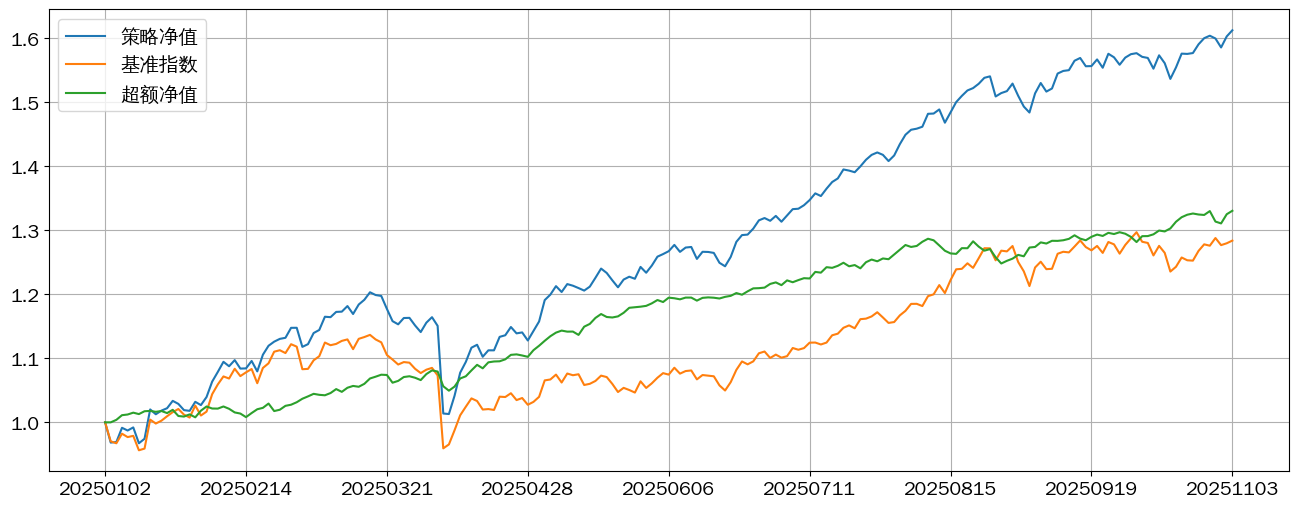

In [31]:
citic_limit_up = round(citic_limit,3)
citic_limit_down = round(citic_limit,3)
cmvg_limit_up = round(cmvg_limit,2)
cmvg_limit_down = round(cmvg_limit,2)
stk_hold_limit_up = round(stk_hold_limit,4)
other_limit_up = round(other_limit,2)
other_limit_down = round(other_limit,2)
stk_buy_r = round(stk_buy_r,4)
turn_max = round(turn_max,2)
mem_hold = round(mem_hold,2)

s = account(initial_money) # 策略初始化
s.cal_tot()

params = {
    'im':initial_money/100000000,
    'cu':citic_limit_up,
    'cd':citic_limit_down,
    'mu':cmvg_limit_up,
    'su':stk_hold_limit_up,
    'mh':mem_hold,
    'ou':other_limit_up,
    'od':other_limit_down,
    'sr':stk_buy_r,
    'tm':turn_max,}

hold_df_dict = {} # 保存每日持仓记录
trade_df_dict = {} # 保存每日交易记录
hold_style_dict = {} # 保存每日持仓风格信息
account_s = {}
cash_s = {}
buy_s = {}
sell_s = {}    
zt_trades = {}

for date in tqdm(date_list[:]):
    
    str_date = date
    s.date = str_date

    td_open,td_close,td_preclose,td_adj,td_score,td_upper,td_lower,last_zt = get_daily_price(date)
    td_citic,td_cmvg,td_mem,zz_citic,zz_cmvg,style_fac,zz_style,sub_code_list = get_daily_support(str_date)
    code_list = pd.concat([td_upper,td_lower,td_close, td_open],axis=1).dropna(how='any').index.tolist() # 今日可交易
    code_list2 = [x for x in code_list if (x in sub_code_list) & (x[0]!='4') & (x[0]!='8')] # 剔除新股,ST股票,北交所股票

    stk_ratio = stk_hold_limit_up / (td_mem.max()+td_mem.max())
    stk_perm = (td_mem+td_mem.max()) * stk_ratio
    zt_codes = last_zt[last_zt==1].index.tolist()

    # 开盘前刷新参数
    account0 = s.refresh_open(td_upper,td_lower,td_preclose.to_dict(),td_adj)
    stk_buy_amt = pd.Series([stk_buy_r*account0]*len(code_list2),index=code_list2)
    for code in zt_codes:
        if code in code_list2:
            stk_buy_amt[code] = 0

    # 获取昨日持仓
    if len(s.hold_dict)==0:
        last_hold = td_mem.reindex(code_list2).fillna(0) * account0 #pd.Series([0]*len(code_list2),index=code_list2)
    else:
        last_hold = hold_df['amt'].reindex(code_list2).fillna(0) + s.cash * td_mem.reindex(code_list2).fillna(0)
        st_hold = hold_df['amt'].reindex([x for x in hold_df.index if (x not in code_list2)]) # 

    try:
        # 通过组合优化，获取当日目标持仓市值
        tgt_hold = solve_problem(code_list2, 
                        x_last=last_hold, 
                        score0= (td_score-td_score.min())/(td_score.max()-td_score.min()), 
                        stk_low0=((td_mem-stk_perm).clip(0) * account0)\
                                    .clip(upper=last_hold+stk_buy_amt,lower=last_hold-2*stk_buy_r*account0), # 每日卖出额为2份，则个股持仓额下限进考虑指数成分股偏离
                        stk_high0=((td_mem+stk_perm) * account0)\
                                    .clip(upper=last_hold+stk_buy_amt,lower=last_hold-2*stk_buy_r*account0), # 考虑指数成分股偏离上限，以及个股当日最多可买一份
                        tot_amt0 = 1.01 * account0, # 适当增加买入任务金额, 避免买入失败而空仓
                        sell_max0 = account0 * turn_max,
                        td_mem0 = (td_mem>0).astype(int),
                        td_mem_amt0 = mem_hold * account0,
                        td_ind0=td_citic,
                        td_ind_up0= ( (zz_citic+citic_limit_up) * account0 ),
                        td_ind_down0=( (zz_citic-citic_limit_down) * account0 ),
                        td_cmvg0=td_cmvg,
                        td_cmvg_up0=( (zz_cmvg+cmvg_limit_up) * account0 ),
                        td_cmvg_down0=( (zz_cmvg-cmvg_limit_down) * account0 ),
                        td_style=style_fac,
                        style_up0=( (zz_style+other_limit_up) * account0),
                        style_down0=( (zz_style-other_limit_down) * account0),
                        solver='SCIPY')
        
        if len(round(tgt_hold).replace(0,np.nan).dropna())==0: # 如果求解失败，换手率放大3倍
            raise ValueError('no target hold')
    except:
        # 当组合求解失败, 默认向指数成分股靠拢换手率比例
        print(str_date, 'no target hold, move toward index')
        tgt_hold = last_hold * (1-turn_max) + td_mem.reindex(code_list2).fillna(0) * turn_max * s.tot_account

    # 根据目标持仓，得到交易任务
    sort_index = td_score.sort_values(ascending=False).index
    if len(s.hold_dict)==0: # 第一天建仓，参考中证1000指数
        to_buy_s = round(tgt_hold).replace(0,np.nan).reindex(sort_index).dropna() # 按打分排序，剔除任务金额为0的股票
        to_buy_s = round( to_buy_s / td_preclose.reindex(to_buy_s.index) ) # 金额转换成量
        to_sell_s = pd.Series(dtype=float)
    else:
        last_hold = hold_df['amt'].reindex(code_list2).fillna(0)
        to_trade_s = round(tgt_hold - last_hold).replace(0,np.nan)
        to_buy_s = to_trade_s[to_trade_s>0].reindex(sort_index).dropna() # 按打分排序，剔除任务金额为0的股票
        to_buy_s = round( to_buy_s / td_preclose.reindex(to_buy_s.index) ) # 金额转换成量
        to_sell_s = pd.concat([st_hold, -to_trade_s[to_trade_s<0].reindex(sort_index).dropna().iloc[::-1]])  # 卖出股票从低分开始排序
        to_sell_s = round( to_sell_s / td_preclose.reindex(to_sell_s.index) ) # 金额转换成量

    max_buy = s.cash
    
    s.fresh_price(td_open.to_dict())
    buy_amt, sell_amt = s.daily_trade(max_buy, to_buy_s, to_sell_s)
    s.fresh_price(td_close.to_dict())
    
    account_s[date] = s.cal_tot()
    cash_s[date] = s.cash
    buy_s[date] = buy_amt
    sell_s[date] = sell_amt
    hold_df, trade_df = s.close_today()
    hold_df_dict[date] = hold_df
    trade_df_dict[date] = trade_df
    zt_trades[date] = trade_df[trade_df['code'].isin(zt_codes)]

    hold_weight = hold_df['amt'] / hold_df['amt'].sum()
    td_citic_diff = td_citic.reindex(hold_weight.index).fillna(0).T.dot(hold_weight) - zz_citic
    td_cmvg_diff = td_cmvg.reindex(hold_weight.index).fillna(0).T.dot(hold_weight) - zz_cmvg
    td_style_diff = style_fac.reindex(hold_weight.index).fillna(0).T.dot(hold_weight) - zz_style
    td_mem_hold = hold_weight.reindex(td_mem[td_mem>0].index).fillna(0).sum()
    td_diff = pd.concat([td_citic_diff, td_cmvg_diff, td_style_diff])
    td_diff['idx_hold'] = td_mem_hold
    hold_style_dict[date] = td_diff

tot_account_s = pd.concat([pd.Series(account_s), pd.Series(cash_s), pd.Series(buy_s), pd.Series(sell_s)],axis=1,keys=['tot_account','cash','buy_amt','sell_amt'])
hold_style_diff = pd.DataFrame(hold_style_dict).T

ans_dict = {'tot_account_s':tot_account_s,'hold_df_dict':hold_df_dict,'trade_df_dict':trade_df_dict,
            'account':s,'params':params,'hold_style_diff':hold_style_diff}

ret1 = tot_account_s['tot_account']
ret0 = zs_nv.reindex(ret1.index)
ret_df = pd.concat([ret0,ret1],axis=1,keys=['zs','strategy']).ffill()
ret_df = ret_df / ret_df.iloc[0]
ret_df_cumsum = ret_df.pct_change().cumsum()+1
info_s, nv_df, rel_nv = analyse(ret_df_cumsum, True)

In [33]:
tot_account_s

,tot_account,cash,buy_amt,sell_amt
20250102,1.953972e+08,334.108275,1.999997e+08,0.000000e+00
20250103,1.892203e+08,291.627275,1.740533e+07,1.740528e+07
20250106,1.893788e+08,575.776268,1.708121e+07,1.708149e+07
20250107,1.935977e+08,384.305847,1.581771e+07,1.581752e+07
20250108,1.927716e+08,10.305363,1.745656e+07,1.745618e+07
...,...,...,...,...
20251028,3.478965e+08,41.921793,3.125952e+07,3.125813e+07
20251029,3.463821e+08,1082.105230,3.124454e+07,3.124559e+07
20251030,3.415300e+08,4548.346611,3.082582e+07,3.082928e+07
20251031,3.474186e+08,1257.928151,2.929041e+07,2.928712e+07
